# Multi-Resolution Image Blending using Gaussian and Laplacian Pyramids

**Project Topic:** Multi-Resolution Image Blending  
**Core Concepts:** Gaussian Pyramid, Laplacian Pyramid, Image Compositing

## 1. Project Introduction

This notebook demonstrates multi-resolution image blending using Gaussian and Laplacian pyramids.

## 2. Import Required Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

## 3. Mount Google Drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Set Image Paths


In [ ]:
IMG1_PATH = "/content/drive/MyDrive/cse-438( Image Processing )/Project/1000x1000__greenapple1000x1000-1633937107305.jpg"
IMG2_PATH = "/content/drive/MyDrive/cse-438( Image Processing )/Project/close-up-delicious-apple_23-2151868338.avif"

## 5. Define Image Loading Function

In [ ]:
def load_image_rgb(path):
    img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)

    if img_bgr is None:
        raise ValueError(f"Could not read image from: {path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb

## 6. Load Input Images

In [ ]:
img1_original = load_image_rgb(IMG1_PATH)
img2_original = load_image_rgb(IMG2_PATH)

print("Image A Shape:", img1_original.shape)
print("Image B Shape:", img2_original.shape)

Image A Shape: (1000, 1000, 3)
Image B Shape: (626, 594, 3)


## 7. Display Original Images

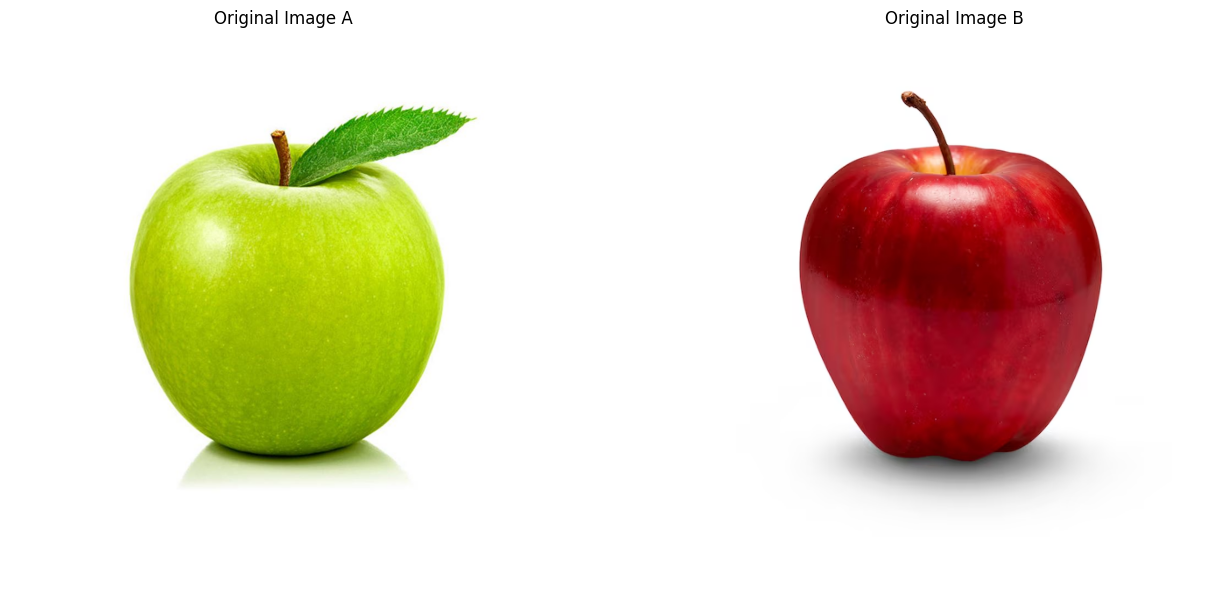

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img1_original)
axes[0].set_title("Original Image A")
axes[0].axis("off")

axes[1].imshow(img2_original)
axes[1].set_title("Original Image B")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 8. Set Target Size

In [ ]:
TARGET_SIZE = (512, 512)  # (width, height)
TARGET_SIZE

(512, 512)

## 9. Resize Images

In [ ]:
img1_resized = cv2.resize(img1_original, TARGET_SIZE, interpolation=cv2.INTER_AREA)
img2_resized = cv2.resize(img2_original, TARGET_SIZE, interpolation=cv2.INTER_AREA)

print("Resized Image A Shape:", img1_resized.shape)
print("Resized Image B Shape:", img2_resized.shape)

Resized Image A Shape: (512, 512, 3)
Resized Image B Shape: (512, 512, 3)


## 10. Normalize Images

In [ ]:
img1 = img1_resized.astype(np.float32) / 255.0
img2 = img2_resized.astype(np.float32) / 255.0

height, width = img1.shape[:2]

print("Normalized Image Shape:", img1.shape)
print("Data Type:", img1.dtype)

Normalized Image Shape: (512, 512, 3)
Data Type: float32


## 11. Display Processed Images

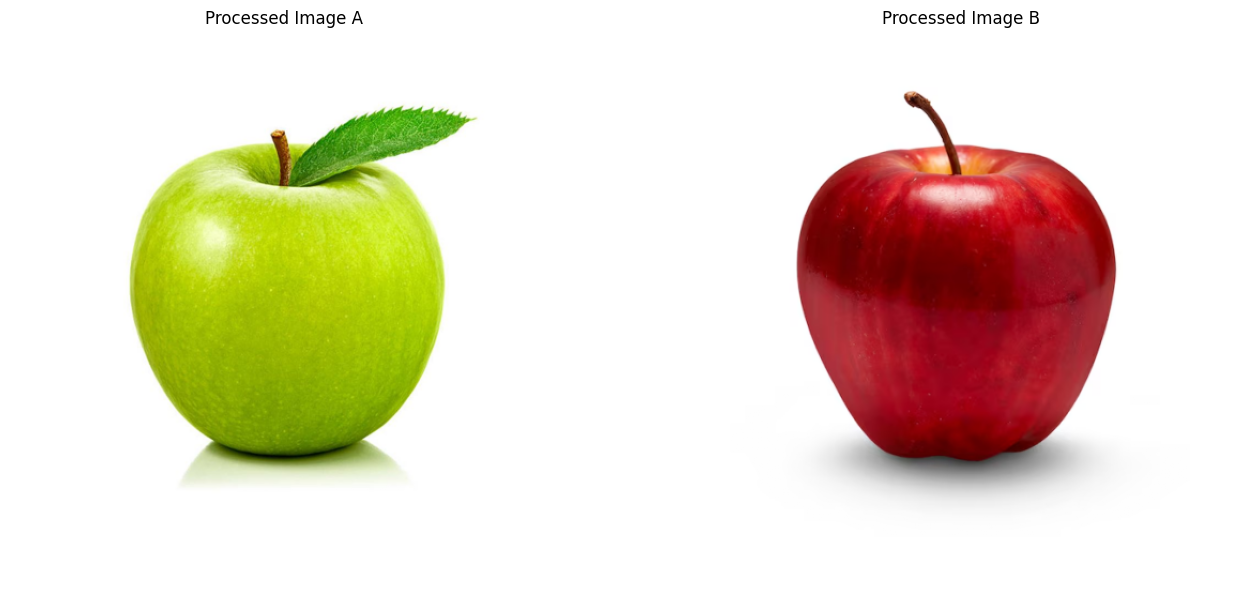

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img1)
axes[0].set_title("Processed Image A")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("Processed Image B")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 12. Define Mask Creation Function

In [ ]:
def create_horizontal_gradient_mask(height, width, transition_ratio=0.20):
    mask = np.zeros((height, width), dtype=np.float32)

    center = width // 2
    transition_width = int(width * transition_ratio)

    left_end = max(center - transition_width // 2, 0)
    right_start = min(center + transition_width // 2, width)

    mask[:, :left_end] = 1.0

    if right_start > left_end:
        gradient = np.linspace(1.0, 0.0, right_start - left_end, dtype=np.float32)
        mask[:, left_end:right_start] = gradient

    mask[:, right_start:] = 0.0

    mask_3ch = np.dstack([mask, mask, mask])
    return mask_3ch

## 13. Create the Blending Mask

In [ ]:
TRANSITION_RATIO = 0.20
mask = create_horizontal_gradient_mask(height, width, transition_ratio=TRANSITION_RATIO)

print("Mask Shape:", mask.shape)

Mask Shape: (512, 512, 3)


## 14. Display the Mask

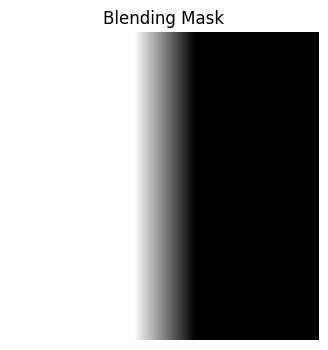

In [ ]:
plt.figure(figsize=(10, 4))
plt.imshow(mask[:, :, 0], cmap="gray")
plt.title("Blending Mask")
plt.axis("off")
plt.show()

## 15. Set Pyramid Levels

In [ ]:
LEVELS = 6
LEVELS

6

## 16. Define Gaussian Pyramid Function

In [ ]:
def build_gaussian_pyramid(image, levels=6):
    pyramid = [image]
    current = image.copy()

    for _ in range(levels - 1):
        current = cv2.pyrDown(current)
        pyramid.append(current)

    return pyramid

## 17. Define Laplacian Pyramid Function

In [ ]:
def build_laplacian_pyramid(gaussian_pyramid):
    laplacian_pyramid = []

    for i in range(len(gaussian_pyramid) - 1):
        current = gaussian_pyramid[i]
        next_level = gaussian_pyramid[i + 1]

        expanded = cv2.pyrUp(next_level, dstsize=(current.shape[1], current.shape[0]))
        laplacian = current - expanded
        laplacian_pyramid.append(laplacian)

    laplacian_pyramid.append(gaussian_pyramid[-1])
    return laplacian_pyramid

## 18. Define Display Helper Functions

In [ ]:
def normalize_for_display(image):
    img = image.copy()
    min_val = img.min()
    max_val = img.max()

    if max_val - min_val < 1e-8:
        return np.zeros_like(img)

    return (img - min_val) / (max_val - min_val)


def show_pyramid(pyramid, title_prefix="Level", normalize=False):
    n = len(pyramid)
    plt.figure(figsize=(4 * n, 4))

    for i, level in enumerate(pyramid):
        plt.subplot(1, n, i + 1)

        if normalize:
            display_img = normalize_for_display(level)
        else:
            display_img = np.clip(level, 0.0, 1.0)

        plt.imshow(display_img)
        plt.title(f"{title_prefix} {i}\n{level.shape[1]} x {level.shape[0]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## 19. Build Gaussian Pyramids

In [ ]:
gp_img1 = build_gaussian_pyramid(img1, LEVELS)
gp_img2 = build_gaussian_pyramid(img2, LEVELS)
gp_mask = build_gaussian_pyramid(mask, LEVELS)

print("Gaussian pyramids created successfully.")

Gaussian pyramids created successfully.


## 20. Visualize Gaussian Pyramids

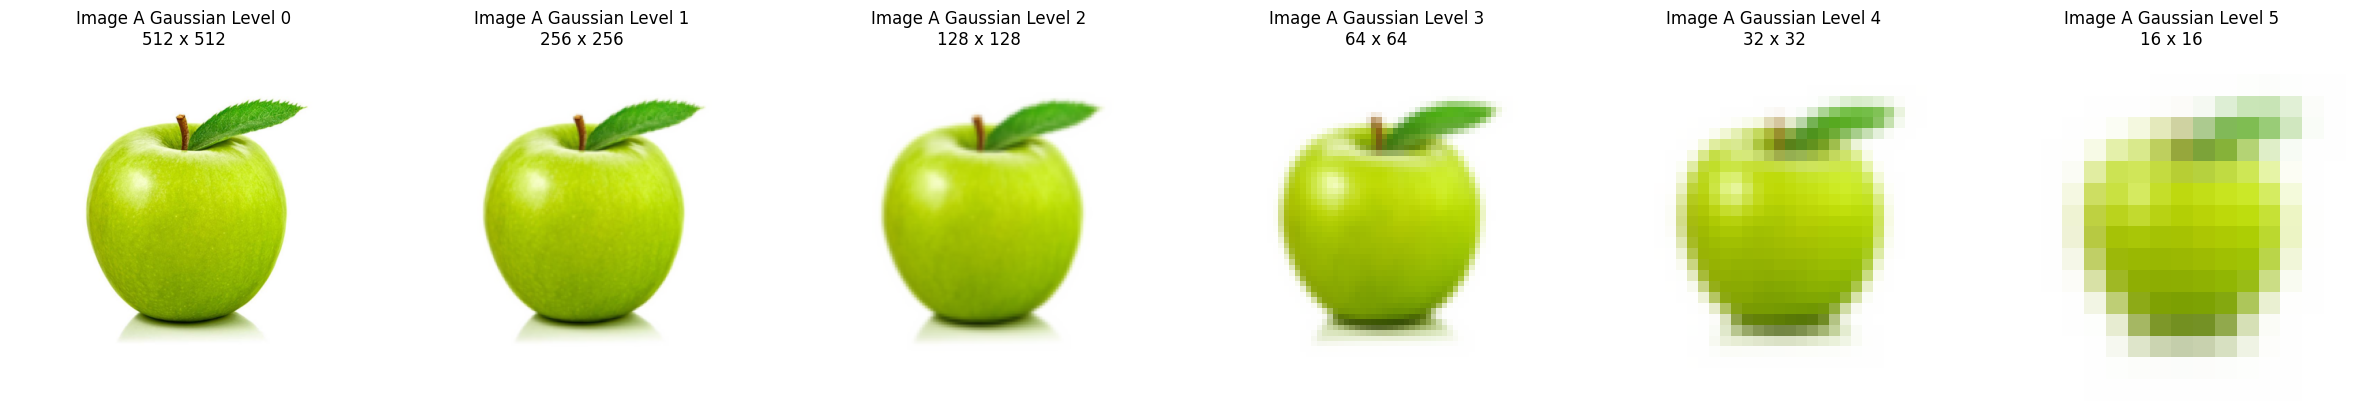

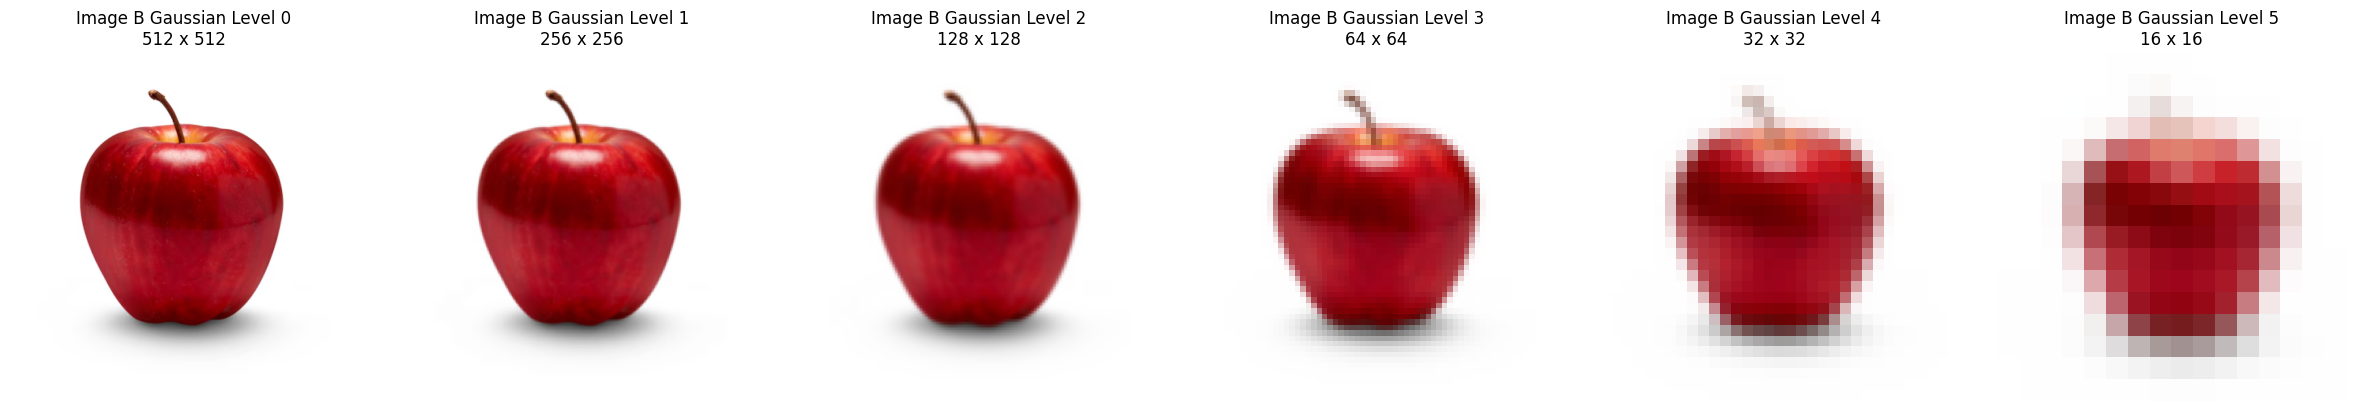

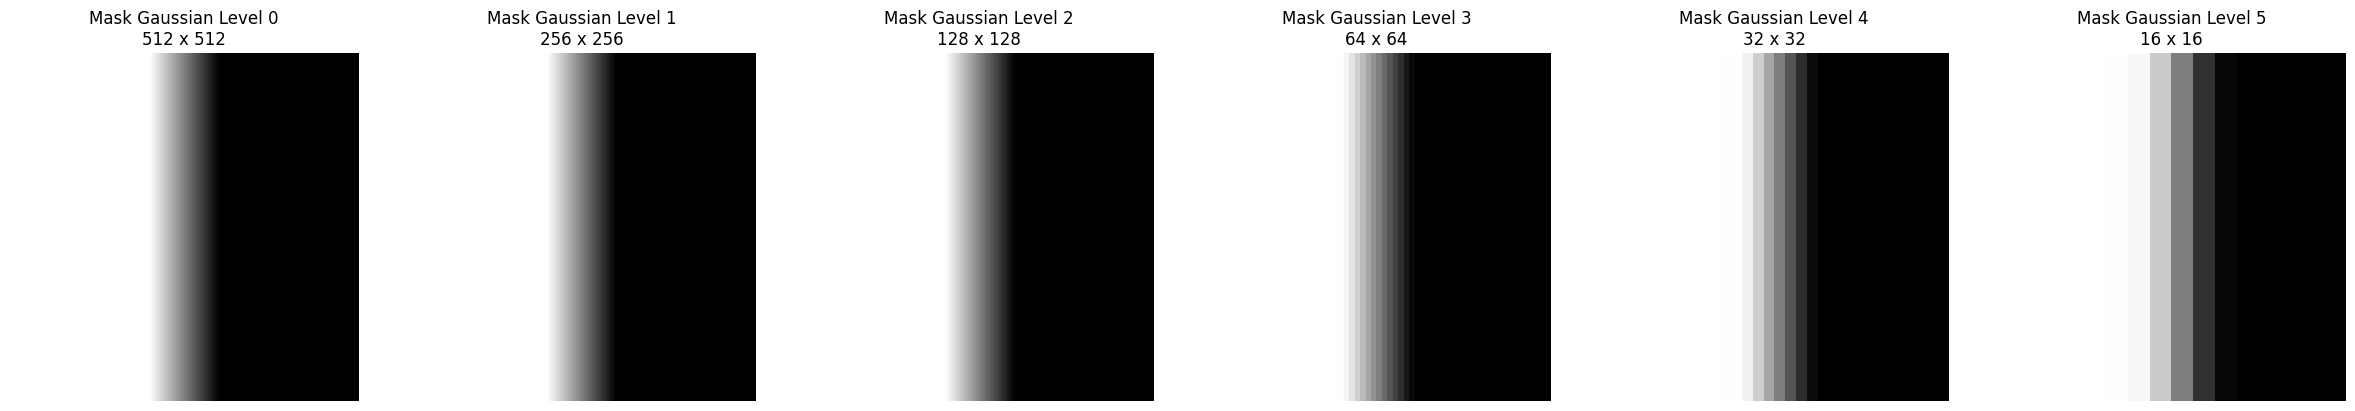

In [ ]:
show_pyramid(gp_img1, title_prefix="Image A Gaussian Level", normalize=False)
show_pyramid(gp_img2, title_prefix="Image B Gaussian Level", normalize=False)
show_pyramid(gp_mask, title_prefix="Mask Gaussian Level", normalize=False)

## 21. Build Laplacian Pyramids

In [ ]:
lp_img1 = build_laplacian_pyramid(gp_img1)
lp_img2 = build_laplacian_pyramid(gp_img2)

print("Laplacian pyramids created successfully.")

Laplacian pyramids created successfully.


## 22. Visualize Laplacian Pyramids

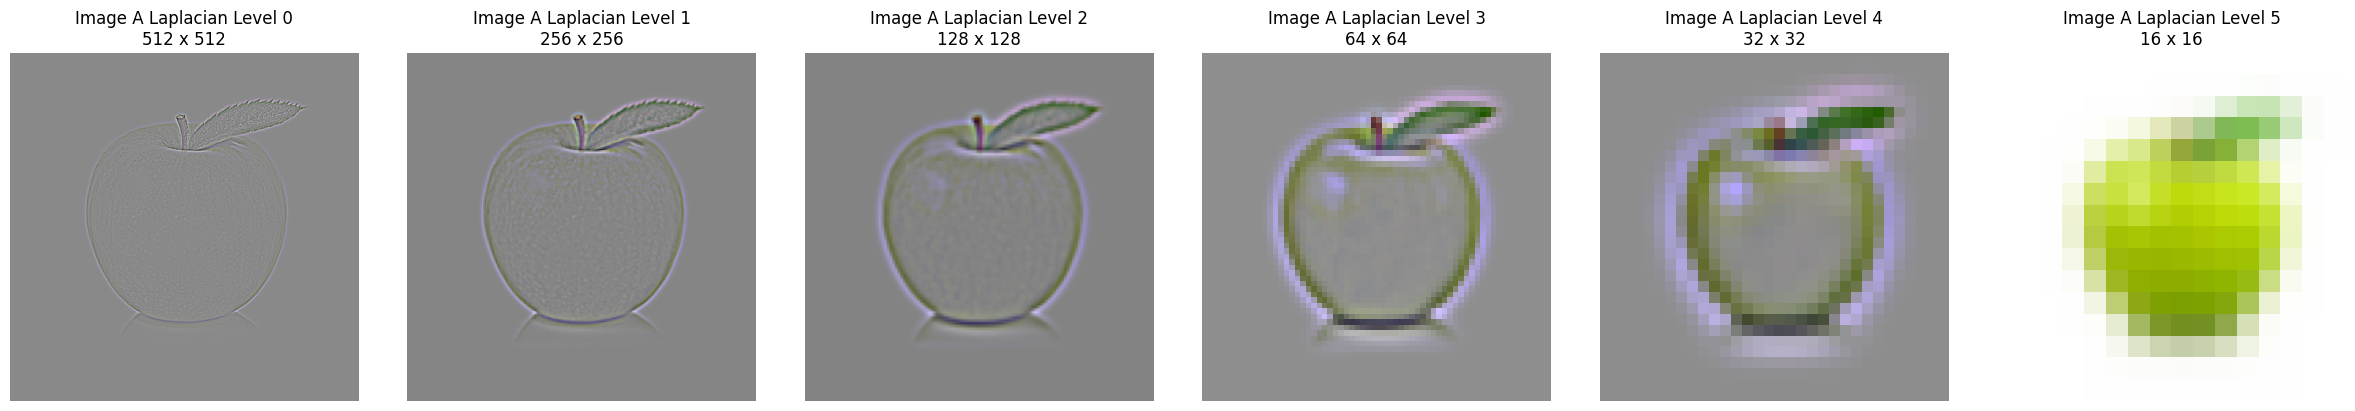

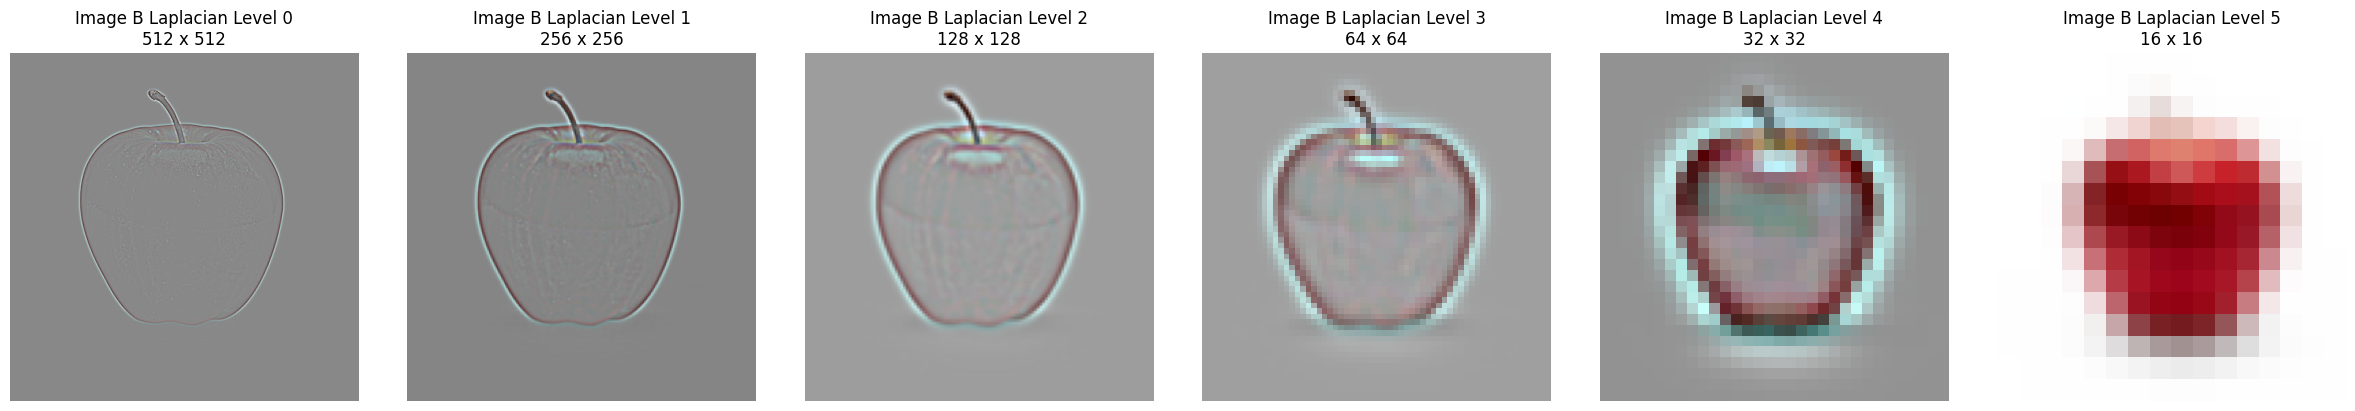

In [ ]:
show_pyramid(lp_img1, title_prefix="Image A Laplacian Level", normalize=True)
show_pyramid(lp_img2, title_prefix="Image B Laplacian Level", normalize=True)

## 23. Blend Pyramid Levels

In [ ]:
blended_pyramid = []

for la, lb, gm in zip(lp_img1, lp_img2, gp_mask):
    blended_level = gm * la + (1.0 - gm) * lb
    blended_pyramid.append(blended_level)

print("Pyramid blending completed.")

Pyramid blending completed.


## 24. Visualize Blended Pyramid

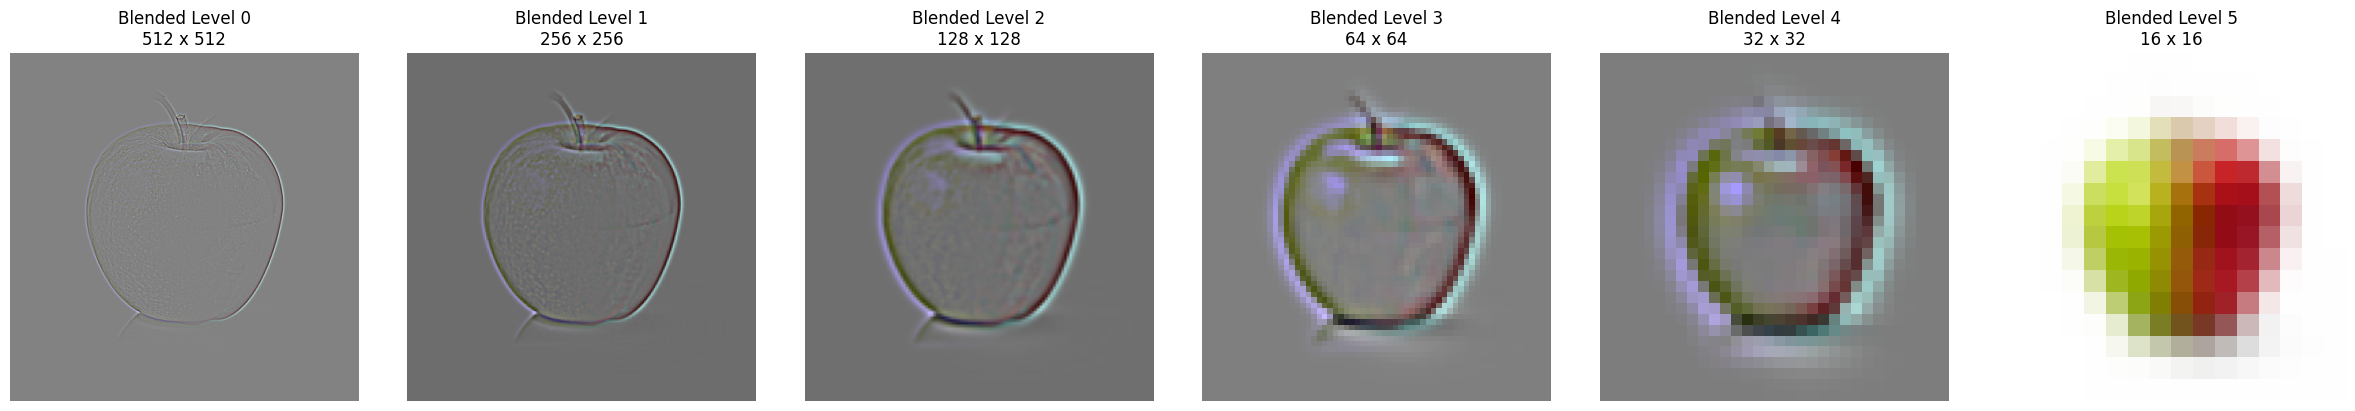

In [ ]:
show_pyramid(blended_pyramid, title_prefix="Blended Level", normalize=True)

## 25. Define Reconstruction Function

In [ ]:
def reconstruct_from_laplacian_pyramid(laplacian_pyramid):
    current = laplacian_pyramid[-1]

    for i in range(len(laplacian_pyramid) - 2, -1, -1):
        current = cv2.pyrUp(current, dstsize=(laplacian_pyramid[i].shape[1], laplacian_pyramid[i].shape[0]))
        current = current + laplacian_pyramid[i]

    return np.clip(current, 0.0, 1.0)

## 26. Reconstruct the Final Blended Image

In [ ]:
blended_result = reconstruct_from_laplacian_pyramid(blended_pyramid)
print("Reconstruction completed.")

Reconstruction completed.


## 27. Display Final Blended Output

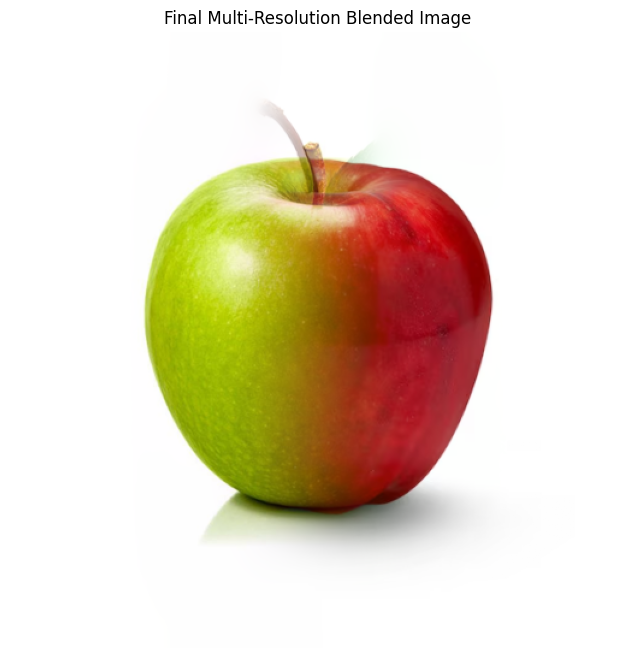

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(blended_result)
plt.title("Final Multi-Resolution Blended Image")
plt.axis("off")
plt.show()

## 28. Create Direct Blend for Comparison

In [ ]:
direct_blend = mask * img1 + (1.0 - mask) * img2

## 29. Compare Direct Blending and Pyramid Blending

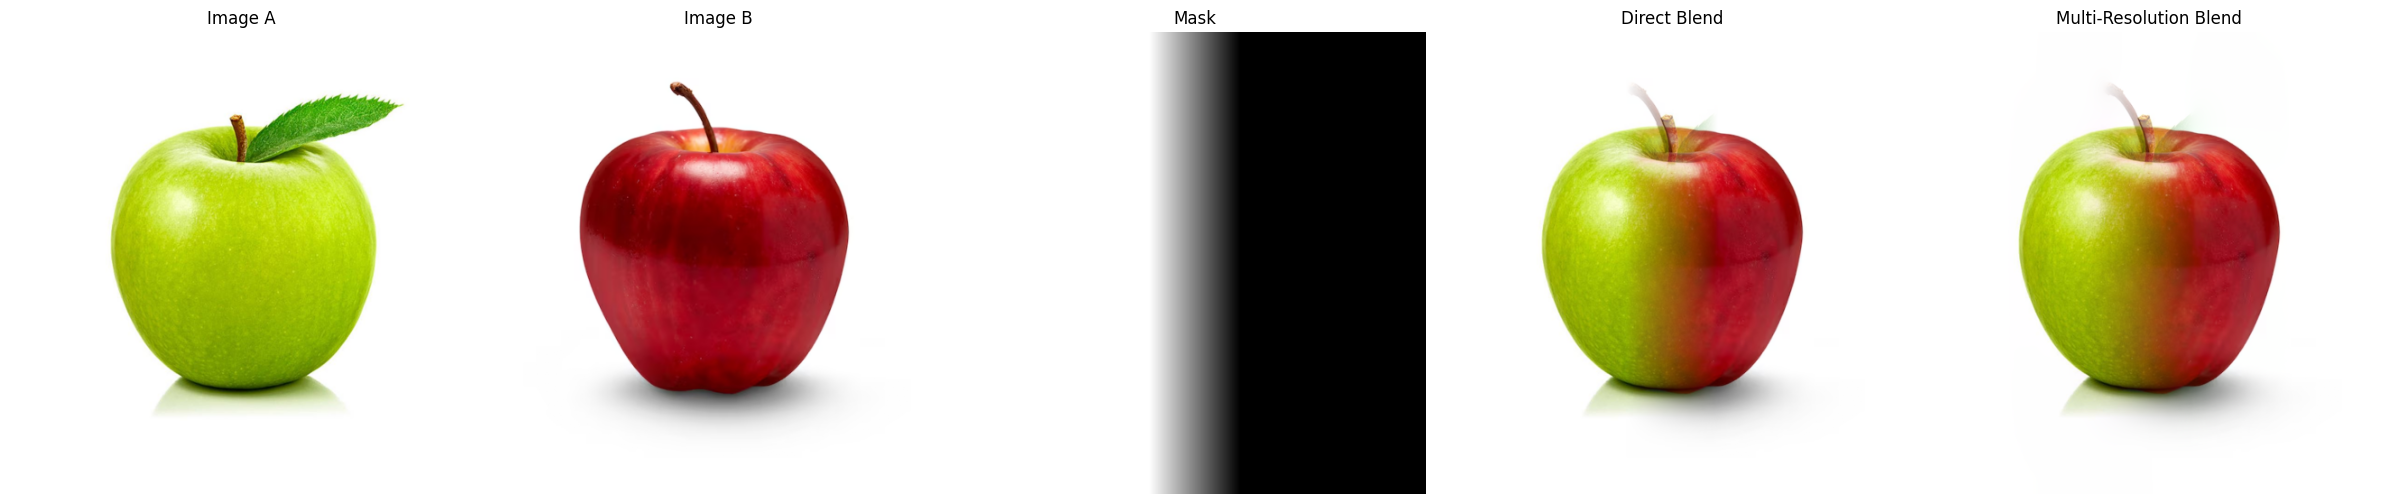

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(24, 6))

axes[0].imshow(img1)
axes[0].set_title("Image A")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("Image B")
axes[1].axis("off")

axes[2].imshow(mask[:, :, 0], cmap="gray")
axes[2].set_title("Mask")
axes[2].axis("off")

axes[3].imshow(np.clip(direct_blend, 0.0, 1.0))
axes[3].set_title("Direct Blend")
axes[3].axis("off")

axes[4].imshow(blended_result)
axes[4].set_title("Multi-Resolution Blend")
axes[4].axis("off")

plt.tight_layout()
plt.show()

## 30. Optional: Check Pyramid Shapes

In [ ]:
print("Gaussian Pyramid Shapes (Image A):")
for i, level in enumerate(gp_img1):
    print(f"Level {i}: {level.shape}")

print("Laplacian Pyramid Shapes (Image A):")
for i, level in enumerate(lp_img1):
    print(f"Level {i}: {level.shape}")

Gaussian Pyramid Shapes (Image A):
Level 0: (512, 512, 3)
Level 1: (256, 256, 3)
Level 2: (128, 128, 3)
Level 3: (64, 64, 3)
Level 4: (32, 32, 3)
Level 5: (16, 16, 3)
Laplacian Pyramid Shapes (Image A):
Level 0: (512, 512, 3)
Level 1: (256, 256, 3)
Level 2: (128, 128, 3)
Level 3: (64, 64, 3)
Level 4: (32, 32, 3)
Level 5: (16, 16, 3)
